In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df2 = pd.read_csv('D:\datasets\\Mall_Customers.csv')

df2.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [17]:
# kmeans clustering on Mall_Customers dataset

kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=0)

kmeans.fit(df2[['Annual Income (k$)', 'Spending Score (1-100)']])



,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


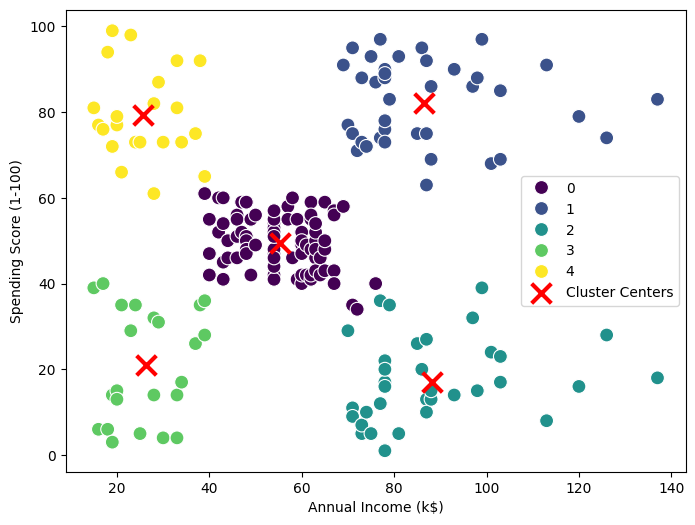

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df2['Annual Income (k$)'], y=df2['Spending Score (1-100)'], hue=kmeans.labels_, palette='viridis', s=100)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, linewidths=3, label='Cluster Centers')
plt.legend()
plt.show()

In [19]:
# evaluating the model using silhouette score

from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(df2[['Annual Income (k$)', 'Spending Score (1-100)']], kmeans.labels_)
print("The average silhouette score is:", silhouette_avg)

The average silhouette score is: 0.553931997444648


In [4]:
import pickle

with open ('D:\\datasets\\kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

In [5]:
with open ('D:\\datasets\\kmeans_model.pkl', 'rb') as f:
    loaded_kmeans2 = pickle.load(f)